In [17]:
import pandas as pd
import json
import matplotlib.pyplot as plt

In [18]:
experiments = [
    {"id": "exp_20250627_145610", "name": "Openwhisk"},
    {"id": "exp_20250627_103341", "name": "Proposed"},
    {"id": "exp_20250627_213220", "name": "Histogram"},
    {"id": "exp_20250628_065241", "name": "Pagurus"},
]
experiment_id="exp_20250628_065241"

mem_cost_per_sec_per_mb = 0.00001
cpu_cost_per_sec= 0.00005
memory_mb = 1024

In [19]:
# Placeholder for plotting data
plot_data = {}

# Iterate over all experiments
for exp in experiments:
    # Load your dataframe here. Replace with actual loading logic:
    path = f"../results/{exp['id']}/docker_log.csv"
    df = pd.read_csv(path)
    df = pd.read_csv(path,names=['Timestamp','name','image','status'])

    start_time = df['Timestamp'].min()
    df['ElapsedTime'] = (df['Timestamp'] - start_time) / 1000  # in seconds
    
    
    # Process timestamps
    timestamps = sorted(df['Timestamp'].unique())

    # Build container status per timestamp
    container_status = {}
    for name, group in df.groupby('name'):
        group = group.sort_values('Timestamp')
        status_list = []
        last_status = None
        idx = 0
        for t in timestamps:
            while idx < len(group) and group.iloc[idx]['Timestamp'] <= t:
                last_status = group.iloc[idx]['status']
                idx += 1
            status_list.append(last_status)
        container_status[name] = status_list

    # Calculate cumulative cost
    cumulative_costs = []
    total_cost = 0.0
    for i in range(1, len(timestamps)):
        interval_sec = (timestamps[i] - timestamps[i-1]) / 1000.0
        for name, status_list in container_status.items():
            status = status_list[i-1]
            if status is None:
                continue
            mem_cost = interval_sec * mem_cost_per_sec_per_mb * memory_mb
            if status == 'running':
                cpu_cost = interval_sec * cpu_cost_per_sec
                total_cost += mem_cost + cpu_cost
            elif status == 'paused':
                total_cost += mem_cost
        cumulative_costs.append(total_cost)

    elapsed_secs = [(t - timestamps[0]) / 1000 for t in timestamps[1:]]
    plot_data[exp['name']] = (elapsed_secs, cumulative_costs)


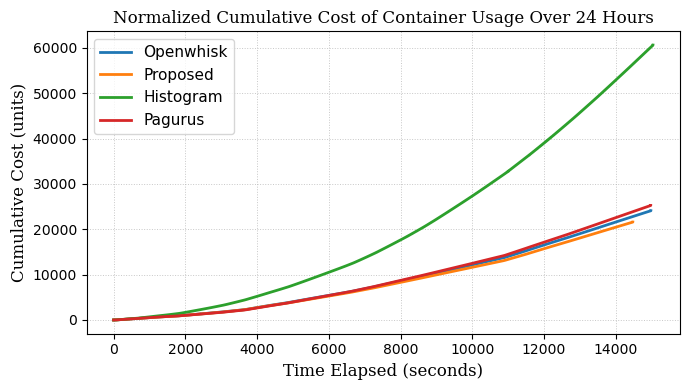

In [4]:
# Plotting IEEE-style graph
plt.figure(figsize=(7, 4))
font = {'family': 'serif', 'size': 12}

for name, (x, y) in plot_data.items():
    plt.step(x, y, where='post', linewidth=2, label=name)

plt.xlabel('Time Elapsed (seconds)', fontdict=font)
plt.ylabel('Cumulative Cost (units)', fontdict=font)
plt.title('Normalized Cumulative Cost of Container Usage Over 24 Hours', fontdict=font)
plt.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
# plt.savefig('cumulative_cost_comparison_ieee.pdf', dpi=300)
plt.show()

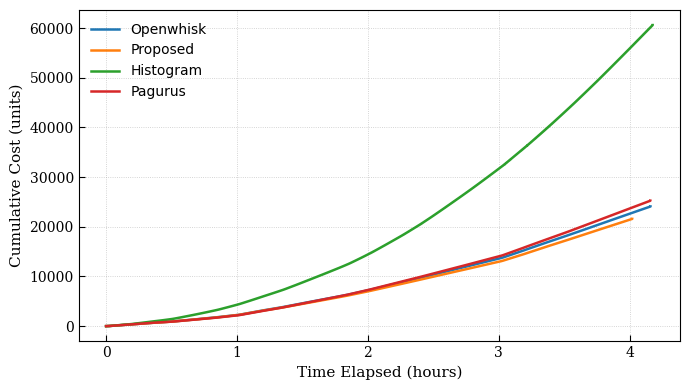

In [5]:
# Convert x-values from seconds to hours
plt.figure(figsize=(7, 4))
font = {'family': 'serif', 'size': 11}

for name, (x, y) in plot_data.items():
    x_hours = [t / 3600.0 for t in x]
    plt.step(x_hours, y, where='post', linewidth=1.8, label=name)

plt.xlabel('Time Elapsed (hours)', fontdict=font)
plt.ylabel('Cumulative Cost (units)', fontdict=font)
# IEEE style: usually no title on graph, title goes in caption
plt.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)
plt.legend(loc='upper left', fontsize=10, frameon=False)
plt.xticks(fontsize=10, fontname='serif')
plt.yticks(fontsize=10, fontname='serif')
plt.tick_params(direction='in', length=4, width=0.8)
plt.tight_layout()
# plt.savefig('cumulative_cost_comparison_ieee.pdf', dpi=300)
plt.show()


NameError: name 'axins' is not defined

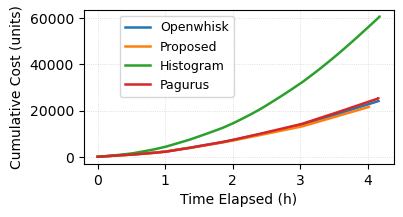

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Figure setup for IEEE single-column size
plt.figure(figsize=(4, 2.0))
ax = plt.gca()

# Compute final time horizon
t_end_sec = max(max(x) for x, y in plot_data.values())
t_end_h = t_end_sec / 3600.0

# Main plot with solid lines
for label, (x, y) in plot_data.items():
    hrs = [sec / 3600.0 for sec in x]
    ax.step(hrs, y, where='post', linewidth=1.8, label=label)

# Axis labels, limits, and grid
# plt.xlim(0, t_end_h)
plt.xlabel("Time Elapsed (h)")
plt.ylabel("Cumulative Cost (units)")
plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

# Legend above the main plot
ax.legend(loc='upper center', bbox_to_anchor=(0.3, 1),
          ncol=1, framealpha=0.8, fontsize=9)

# # Inset plot: zoom into last 1 hour
# axins = inset_axes(ax, width="35%", height="35%", loc='upper right', borderpad=0.8)
# zoom_start = t_end_h - 1
# zoom_end = t_end_h

for label, (x, y) in plot_data.items():
    hrs = [sec / 3600.0 for sec in x]
    axins.step(hrs, y, where='post', linewidth=1.8)

axins.set_xlim(zoom_start, zoom_end)
axins.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)
axins.tick_params(labelsize=7)

plt.tight_layout(pad=0.2)
# plt.savefig('cumulative_cost_ieee_with_inset_solidlines.pdf', dpi=600, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
# Step 1: Clean plot_data by removing bad entries
cleaned_plot_data = {}

for label, (x_vals, y_vals) in plot_data.items():
    x_clean = []
    y_clean = []
    for x, y in zip(x_vals, y_vals):
        try:
            x = float(x)
            x_clean.append(x)
            y_clean.append(y)
        except ValueError:
            print(f"⚠️ Skipping non-numeric timestamp '{x}' in '{label}'")
            continue
    cleaned_plot_data[label] = (x_clean, y_clean)

# Step 2: Compute overall time horizon (in hours)
t_end_sec = max(max(x) for x, _ in cleaned_plot_data.values())
t_end_h = t_end_sec / 3600.0

# Step 3: Plot main figure
plt.figure(figsize=(4, 2.0))
ax = plt.gca()

# Plot each method with solid lines
for label, (x, y) in cleaned_plot_data.items():
    hrs = [t / 3600.0 for t in x]
    ax.step(hrs, y, where='post', linewidth=1.8, label=label)

# Axis labels and grid
plt.xlabel("Time Elapsed (h)")
plt.ylabel("Cumulative Cost (units)")
plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

# Legend above the plot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.22),
          ncol=2, framealpha=0.8, fontsize=9)

# Step 4: Inset (0 to 4 hours zoom)
axins = inset_axes(ax, width="35%", height="35%", loc='upper right', borderpad=0.8)
zoom_start = 0
zoom_end = 4

for label, (x, y) in cleaned_plot_data.items():
    hrs = [t / 3600.0 for t in x]
    axins.step(hrs, y, where='post', linewidth=1.4)

axins.set_xlim(zoom_start, zoom_end)
axins.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)
axins.tick_params(labelsize=7)

plt.tight_layout(pad=0.2)
# plt.savefig('cumulative_cost_ieee_with_inset_cleaned.pdf', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Clean plot_data: ensure all x-values are float
cleaned_plot_data = {}
for label, (x_vals, y_vals) in plot_data.items():
    x_clean = []
    y_clean = []
    for x, y in zip(x_vals, y_vals):
        try:
            x = float(x)
            x_clean.append(x)
            y_clean.append(y)
        except ValueError:
            continue
    cleaned_plot_data[label] = (x_clean, y_clean)

# Determine execution end times
execution_end_times = {label: max(x) for label, (x, _) in cleaned_plot_data.items()}
min_end_time = min(execution_end_times.values())
t_end_h = max(execution_end_times.values()) / 3600.0
min_end_h = min_end_time / 3600.0

# Set up IEEE-style figure
plt.figure(figsize=(4, 2.0))
ax = plt.gca()
ax.set_xlim(0,4.75)

# Plot each curve
for label, (x, y) in cleaned_plot_data.items():
    hrs = [t / 3600.0 for t in x]
    ax.step(hrs, y, where='post', linewidth=1.8, label=label)

# Add dotted horizontal line to show execution time difference
for label, (x, y) in cleaned_plot_data.items():
    end_time = execution_end_times[label]
    if end_time > min_end_time:
        end_cost = y[-1]

        # Highlight execution time difference
        # ax.hlines(y=end_cost,
        #           xmin=min_end_h,
        #           xmax=end_time / 3600.0,
        #           linestyles='--',
        #           linewidth=2.0,
        #           color='orangered')
        end_cost_offset = end_cost
        # if label == "Openwhisk":
        #     end_cost_offset += 524788
        # elif label == "Pagurus":
        #     end_cost_offset -= 524788

        # End point marker
        # ax.plot(end_time / 3600.0, end_cost,
        #         marker='o', color='orangered', markersize=1)

        # Optional annotation
        extra_time = (end_time - min_end_time) / 3600.0
        ax.text((end_time / 3600.0) + 0.1, end_cost_offset,
                f"+{extra_time:.1f}h",
                fontsize=8, color='orangered', va='center')


# Labels, grid, legend
plt.xlabel("Time Elapsed (h)")
plt.ylabel("Cumulative Cost (units)")
plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

ax.legend(loc='upper center', bbox_to_anchor=(0.3, 1),
          ncol=1, framealpha=0.8, fontsize=9)

plt.tight_layout(pad=0.2)
plt.savefig('cumulative_cost_execution_lines_nozoom.jpg', dpi=600, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
for label, (x, y) in cleaned_plot_data.items():
    print(label,max(x))

In [ ]:
import matplotlib.pyplot as plt

# Clean plot_data: ensure all x-values are float
cleaned_plot_data = {}
for label, (x_vals, y_vals) in plot_data.items():
    x_clean = []
    y_clean = []
    for x, y in zip(x_vals, y_vals):
        try:
            x = float(x)
            x_clean.append(x)
            y_clean.append(y)
        except ValueError:
            continue
    cleaned_plot_data[label] = (x_clean, y_clean)

# Determine execution end times
execution_end_times = {label: max(x) for label, (x, _) in cleaned_plot_data.items()}
# min_end_time = min(execution_end_times.values())
min_end_time = 14400
t_end_h = max(execution_end_times.values()) / 3600.0
min_end_h = min_end_time / 3600.0

# Set up IEEE-style figure
plt.figure(figsize=(4, 2.0))
ax = plt.gca()

# Plot each curve
for label, (x, y) in cleaned_plot_data.items():
    hrs = [t / 3600.0 for t in x]
    ax.step(hrs, y, where='post', linewidth=1.8, label=label)

# Add horizontal line + marker + label for execution time difference
for label, (x, y) in cleaned_plot_data.items():
    end_time = execution_end_times[label]
    if end_time > min_end_time:
        end_cost = y[-1]
        extra_time = (end_time - min_end_time) / 3600.0
        end_hour = end_time / 3600.0

        # Horizontal line to show extra execution time
        ax.hlines(y=end_cost,
                  xmin=min_end_h,
                  xmax=end_hour,
                  linestyles='--',
                  linewidth=2.0,
                  color='orangered')

        # # End point marker
        ax.plot(end_hour, end_cost, marker='o',
                color='orangered', markersize=5)

        # Manual vertical offset by label
        y_offset = 0
        if label == "Openwhisk":
            y_offset = 90
            # print('Openwhisk']
        elif label == "Pagurus":
            y_offset = -90

        # Add time delta annotation
        ax.text(end_hour + 0.1, end_cost + y_offset,
                f"+{extra_time:.1f}h",
                fontsize=8, color='orangered',
                )

# Labels, grid, legend
plt.xlabel("Time Elapsed (h)")
plt.ylabel("Cumulative Cost (units)")
plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

ax.legend(loc='upper center', bbox_to_anchor=(0.3, 1),
          ncol=1, framealpha=0.8, fontsize=9)

plt.tight_layout(pad=0.2)
# plt.savefig('cumulative_cost_execution_lines_nozoom_offset.pdf', dpi=600, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.ticker import ScalarFormatter

import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Serif'

color_map = {
    "NMIG": "#00736b",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728"
}

# Clean plot_data: ensure all x-values are float
cleaned_plot_data = {}
for label, (x_vals, y_vals) in plot_data.items():
    x_clean = []
    y_clean = []
    for x, y in zip(x_vals, y_vals):
        try:
            x = float(x)
            x_clean.append(x)
            y_clean.append(y)
        except ValueError:
            continue
    cleaned_plot_data[label] = (x_clean, y_clean)

# Determine execution end times
execution_end_times = {label: max(x) for label, (x, _) in cleaned_plot_data.items()}
# min_end_time = min(execution_end_times.values())
min_end_time = 14400
t_end_h = max(execution_end_times.values()) / 3600.0
min_end_h = min_end_time / 3600.0

# Set up IEEE-style figure
plt.figure(figsize=(4, 2.0))
ax = plt.gca()

# --- Remove top and right borders ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot each curve and store line colors
line_colors = {}
for label, (x, y) in cleaned_plot_data.items():
    hrs = [t / 3600.0 for t in x]
    line, = ax.step(hrs, y, where='post', linewidth=1.8, label=label)
    line_colors[label] = line.get_color()  # store each line's color

# Add horizontal line + marker + label for execution time difference
for label, (x, y) in cleaned_plot_data.items():
    end_time = execution_end_times[label]
    if end_time > min_end_time:
        end_cost = y[-1]
        extra_time = (end_time - min_end_time) / 3600.0
        end_hour = end_time / 3600.0
        line_color = line_colors.get(label, 'orangered')
        line_colors[label] = color


        # Horizontal line
        ax.hlines(y=end_cost,
                  xmin=min_end_h,
                  xmax=end_hour,
                  linestyles='--',
                  linewidth=2.0,
                  color=line_color,
                  alpha=0.8)

        # End point marker
        ax.plot(end_hour, end_cost, marker='o',
                color=line_color, markersize=5)

        # Auto y-offset
        y_offset = 0
        if label == "Openwhisk":
            y_offset = -4000
        elif label == "Pagurus":
            y_offset = 2000
        elif label == "Histogram":
            y_offset = 1
        elif label == "Proposed":
            y_offset = -9000

        # Annotation in matching color
        txt = ax.text(end_hour + 0.1, end_cost + y_offset,
                      f"+{extra_time:.2f}h",
                      fontsize=8, color=line_color, fontweight='bold')
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2.5, foreground='white'),
            path_effects.Normal()
        ])

# Labels, grid, legend
plt.xlabel("Time Elapsed (h)", fontsize=10)
plt.ylabel("Cumulative Cost (units)", fontsize=10)
plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

# --- Use math-style formatting for Y-axis ---
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # always use scientific notation
ax.yaxis.set_major_formatter(formatter)

# Optional: adjust offset text (×10⁴) font size and position
ax.yaxis.get_offset_text().set_fontsize(10)
ax.tick_params(axis='y', which='major', labelsize=10)

# Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.3, 1),
          ncol=1, framealpha=0.8, fontsize=10,labelcolor='linecolor' )

plt.tight_layout(pad=0.1)
# plt.savefig('cumulative_cost_execution_lines_nozoom_offset.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


In [13]:
plot_data.keys()

dict_keys(['Openwhisk', 'Histogram', 'Pagurus', 'NMIG'])

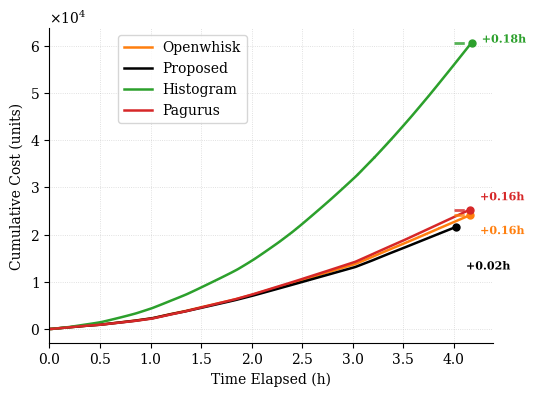

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Serif'

# experiments = [
#     {"id": "exp_20250627_145610", "name": "Openwhisk"},
#     {"id": "exp_20250627_103341", "name": "NMIG"},
#     {"id": "exp_20250627_213220", "name": "Histogram"},
#     {"id": "exp_20250628_065241", "name": "Pagurus"},
# ]
# experiment_id="exp_20250628_065241"
# Rename key 'Proposed' to 'NMIG' in clean_plot_data (if it exists)
# if "Proposed" in plot_data:
#     plot_data["NMIG"] = plot_data.pop("Proposed")

if "NMIG" in plot_data:
    plot_data["Proposed"] = plot_data.pop("NMIG")
    
mem_cost_per_sec_per_mb = 0.00001
cpu_cost_per_sec= 0.00005
memory_mb = 1024

# --- Color map for consistent line colors ---
color_map = {
    "Proposed": "#000000",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728"
}

# --- Clean plot_data ---
cleaned_plot_data = {}
for label, (x_vals, y_vals) in plot_data.items():
    x_clean, y_clean = [], []
    for x, y in zip(x_vals, y_vals):
        try:
            x_clean.append(float(x))
            y_clean.append(y)
        except ValueError:
            continue
    cleaned_plot_data[label] = (x_clean, y_clean)

# --- Determine execution end times ---
execution_end_times = {label: max(x) for label, (x, _) in cleaned_plot_data.items()}
min_end_time = 14400  # 4 hours baseline
t_end_h = max(execution_end_times.values()) / 3600.0
min_end_h = min_end_time / 3600.0

# --- Set up IEEE-style figure ---
plt.figure(figsize=(5.2, 3.8))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Plot each curve and apply color map ---
line_colors = {}
for label, (x, y) in cleaned_plot_data.items():
    hrs = [t / 3600.0 for t in x]
    color = color_map.get(label, 'black')  # fallback if missing
    line, = ax.step(hrs, y, where='post', linewidth=1.8, label=label, color=color)
    line_colors[label] = color  # store used color

# --- Add horizontal execution lines and annotations ---
for label, (x, y) in cleaned_plot_data.items():
    end_time = execution_end_times[label]
    if end_time > min_end_time:
        end_cost = y[-1]
        extra_time = (end_time - min_end_time) / 3600.0
        end_hour = end_time / 3600.0
        line_color = color_map.get(label, 'orangered')

        # Horizontal dashed line
        ax.hlines(y=end_cost,
                  xmin=min_end_h,
                  xmax=end_hour,
                  linestyles='--',
                  linewidth=2.0,
                  color=line_color,
                  alpha=0.8)

        # End marker
        ax.plot(end_hour, end_cost, marker='o', color=line_color, markersize=5)

        # Offset adjustment per label
        y_offset = 0
        if label == "Openwhisk":
            y_offset = -4000
        elif label == "Pagurus":
            y_offset = 2000
        elif label == "Histogram":
            y_offset = 1
        elif label == "Proposed":  # updated from Proposed
            y_offset = -9000

        # Text annotation
        txt = ax.text(end_hour + 0.1, end_cost + y_offset,
                      f"+{extra_time:.2f}h",
                      fontsize=8, color=line_color, fontweight='bold')
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2.5, foreground='white'),
            path_effects.Normal()
        ])
ax.set_xlim(left=0)

# --- Axis labels, grid, and legend ---
plt.xlabel("Time Elapsed (h)", fontsize=14)
plt.ylabel("Cumulative Cost (units)", fontsize=10)
plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.get_offset_text().set_fontsize(10)
ax.tick_params(axis='y', which='major', labelsize=10)

ax.legend(loc='upper center', bbox_to_anchor=(0.3, 1),
          ncol=1, framealpha=0.8, fontsize=10)

plt.tight_layout(pad=0.1)
plt.savefig('graphs_images/cumulative_cost_execution_lines_nozoom_offset_proposed.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()


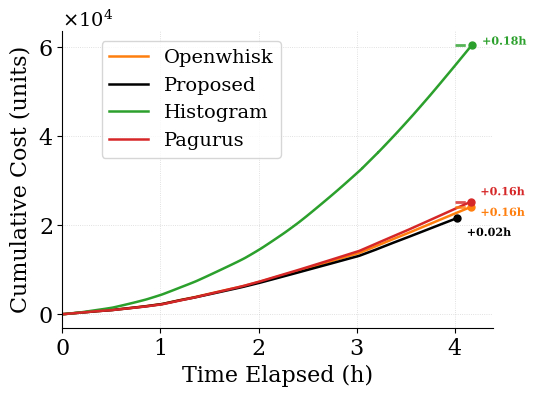

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Serif'

# experiments = [
#     {"id": "exp_20250627_145610", "name": "Openwhisk"},
#     {"id": "exp_20250627_103341", "name": "NMIG"},
#     {"id": "exp_20250627_213220", "name": "Histogram"},
#     {"id": "exp_20250628_065241", "name": "Pagurus"},
# ]
# experiment_id="exp_20250628_065241"
# Rename key 'Proposed' to 'NMIG' in clean_plot_data (if it exists)
# if "Proposed" in plot_data:
#     plot_data["NMIG"] = plot_data.pop("Proposed")

if "NMIG" in plot_data:
    plot_data["Proposed"] = plot_data.pop("NMIG")
    
mem_cost_per_sec_per_mb = 0.00001
cpu_cost_per_sec= 0.00005
memory_mb = 1024

# --- Color map for consistent line colors ---
color_map = {
    "Proposed": "#000000",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728"
}

# --- Clean plot_data ---
cleaned_plot_data = {}
for label, (x_vals, y_vals) in plot_data.items():
    x_clean, y_clean = [], []
    for x, y in zip(x_vals, y_vals):
        try:
            x_clean.append(float(x))
            y_clean.append(y)
        except ValueError:
            continue
    cleaned_plot_data[label] = (x_clean, y_clean)

# --- Determine execution end times ---
execution_end_times = {label: max(x) for label, (x, _) in cleaned_plot_data.items()}
min_end_time = 14400  # 4 hours baseline
t_end_h = max(execution_end_times.values()) / 3600.0
min_end_h = min_end_time / 3600.0

# --- Set up IEEE-style figure ---
plt.figure(figsize=(5.2, 3.8))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Plot each curve and apply color map ---
line_colors = {}
for label, (x, y) in cleaned_plot_data.items():
    hrs = [t / 3600.0 for t in x]
    color = color_map.get(label, 'black')  # fallback if missing
    line, = ax.step(hrs, y, where='post', linewidth=1.8, label=label, color=color)
    line_colors[label] = color  # store used color

# --- Add horizontal execution lines and annotations ---
for label, (x, y) in cleaned_plot_data.items():
    end_time = execution_end_times[label]
    if end_time > min_end_time:
        end_cost = y[-1]
        extra_time = (end_time - min_end_time) / 3600.0
        end_hour = end_time / 3600.0
        line_color = color_map.get(label, 'orangered')

        # Horizontal dashed line
        ax.hlines(y=end_cost,
                  xmin=min_end_h,
                  xmax=end_hour,
                  linestyles='--',
                  linewidth=2.0,
                  color=line_color,
                  alpha=0.8)

        # End marker
        ax.plot(end_hour, end_cost, marker='o', color=line_color, markersize=5)

        # Offset adjustment per label
        y_offset = 0
        if label == "Openwhisk":
            y_offset = -2000
        elif label == "Pagurus":
            y_offset = 1500
        elif label == "Histogram":
            y_offset = 1
        elif label == "Proposed":  # updated from Proposed
            y_offset = -4000

        # Text annotation
        txt = ax.text(end_hour + 0.1, end_cost + y_offset,
                      f"+{extra_time:.2f}h",
                      fontsize=8, color=line_color, fontweight='bold')
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2.5, foreground='white'),
            path_effects.Normal()
        ])
ax.set_xlim(left=0)

# --- Axis labels, grid, and legend ---
plt.xlabel("Time Elapsed (h)", fontsize=16)
plt.ylabel("Cumulative Cost (units)", fontsize=16)
plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.get_offset_text().set_fontsize(14)
ax.tick_params(axis='y', which='major', labelsize=16)
ax.tick_params(axis='x', which='major', labelsize=16)

ax.legend(loc='upper center', bbox_to_anchor=(0.3, 1),
          ncol=1, framealpha=0.8, fontsize=14)

plt.tight_layout(pad=0.1)
plt.savefig('graphs_images/cumulative_cost_execution_lines_nozoom_offset_proposed.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()


In [73]:
max(cleaned_plot_data['Proposed'][1]),max(cleaned_plot_data['Openwhisk'][1]),max(cleaned_plot_data['Histogram'][1]),max(cleaned_plot_data['Pagurus'][1])

(21595.76285938199, 24096.79288921765, 60624.60550430316, 25257.537089182948)

In [75]:
# cleaned_plot_data['Proposed'][1]

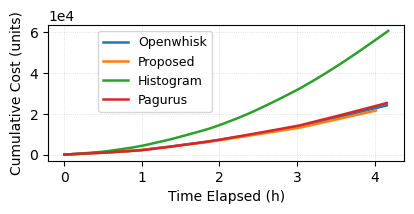

In [38]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker

# # Clean plot_data: ensure all x-values are float
# cleaned_plot_data = {}
# for label, (x_vals, y_vals) in plot_data.items():
#     x_clean = []
#     y_clean = []
#     for x, y in zip(x_vals, y_vals):
#         try:
#             x = float(x)
#             x_clean.append(x)
#             y_clean.append(y)
#         except ValueError:
#             continue
#     cleaned_plot_data[label] = (x_clean, y_clean)

# # Determine execution end times
# execution_end_times = {label: max(x) for label, (x, _) in cleaned_plot_data.items()}
# min_end_time = min(execution_end_times.values())
# t_end_h = max(execution_end_times.values()) / 3600.0
# min_end_h = min_end_time / 3600.0

# # Set up IEEE-style figure
# plt.figure(figsize=(4, 2.0))
# ax = plt.gca()

# # Plot each curve
# for label, (x, y) in cleaned_plot_data.items():
#     end_time = execution_end_times[label]
#     if end_time > min_end_time:
#         end_cost = y[-1]
#         extra_time = (end_time - min_end_time) / 3600.0
#         end_hour = end_time / 3600.0
#         ax.step(hrs, y, where='post', linewidth=1.8, label=label)

# # Use scientific notation for Y-axis
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
# ax.yaxis.get_offset_text().set_fontsize(10)  # smaller offset text (e.g., ×10^5)

# # Labels, grid, legend
# plt.xlabel("Time Elapsed (h)")
# plt.ylabel("Cumulative Cost (units)")
# plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

# ax.legend(loc='upper center', bbox_to_anchor=(0.3, 1),
#           ncol=1, framealpha=0.8, fontsize=9)

# plt.tight_layout(pad=0.2)
# plt.show()


In [33]:
for label, (x_vals, y_vals) in plot_data.items()


SyntaxError: invalid syntax (3868096919.py, line 1)

In [ ]:
max(cleaned_plot_data['Proposed'][1]),max(cleaned_plot_data['Openwhisk'][1]),max(cleaned_plot_data['Histogram'][1]),max(cleaned_plot_data['Pagurus'][1])